# EL Combination Functions


In [ ]:
import os
import pickle
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import ViTForImageClassification, ViTImageProcessor, ViTModel, ViTConfig
from torchvision import transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
from collections import Counter
from torch import nn
from torch.nn import functional as F
import kagglehub
from scipy.stats import mode
import pandas as pd

CHECKPOINT_DIR = './Soup_Saved_5_ViTB'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
SPLIT_FILE = "split_indices.pkl"

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

class ClassBalancedLoss(nn.Module):
    def __init__(self, beta, gamma, reduction='mean'):
        super(ClassBalancedLoss, self).__init__()
        self.beta = beta
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets, samples_per_cls):
        num_classes = logits.size(1)
        effective_num = 1.0 - torch.pow(self.beta, samples_per_cls)
        weights = (1.0 - self.beta) / (effective_num + 1e-8)
        weights = weights / weights.sum() * num_classes
        weights = weights.to(logits.device)
        targets_one_hot = F.one_hot(targets, num_classes=num_classes).float()
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)
        focal_weight = torch.pow(1 - probs, self.gamma)
        cb_loss = -weights.unsqueeze(0) * focal_weight * targets_one_hot * log_probs
        loss = cb_loss.sum(dim=1)
        return loss.mean() if self.reduction == 'mean' else loss.sum()

class ModelOutput:
    def __init__(self, logits):
        self.logits = logits

class HybridModel(nn.Module):
    def __init__(self, num_classes=257, feature_dim=1280, hidden_size=896):
        super().__init__()
        self.cnn = efficientnet_b0(pretrained=True).features
        self.dropout_cnn = nn.Dropout(0.3)
        self.feature_dim = feature_dim
        
        config_vit = ViTConfig(
            hidden_size=hidden_size,
            num_hidden_layers=18,
            num_attention_heads=14,
            intermediate_size=3584,
            image_size=224,
            patch_size=16,
            num_channels=3,
            hidden_dropout_prob=0.35,
            attention_probs_dropout_prob=0.35
        )
        self.vit = ViTModel(config_vit)
        
        self.projection = nn.Linear(feature_dim, hidden_size)
        self.dropout_proj = nn.Dropout(0.3)
        num_patches = 49  # (224/16)^2
        self.positional_embeddings = nn.Parameter(torch.zeros(1, num_patches + 1, hidden_size))
        nn.init.normal_(self.positional_embeddings, std=0.02)
        self.dropout = nn.Dropout(0.35)
        self.ln = nn.LayerNorm(hidden_size)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, pixel_values):
        features = self.cnn(pixel_values)
        features = self.dropout_cnn(features)
        batch_size = features.size(0)
        if features.size(2) != 7 or features.size(3) != 7:
            raise ValueError(f"CNN output spatial dimensions {features.size()[2:]} must be 7x7")
        features = features.view(batch_size, self.feature_dim, -1).permute(0, 2, 1)
        projected_features = self.projection(features)
        projected_features = self.dropout_proj(projected_features)
        cls_token = self.vit.embeddings.cls_token.expand(batch_size, -1, -1)
        embeddings = torch.cat([cls_token, projected_features], dim=1)
        embeddings = embeddings + self.positional_embeddings
        encoder_outputs = self.vit.encoder(embeddings)
        cls_output = encoder_outputs.last_hidden_state[:, 0, :]
        cls_output = self.ln(cls_output)
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return ModelOutput(logits=logits)

class Caltech256Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.images = []
        self.labels = []
        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.endswith(('.jpg', '.jpeg', '.png')):
                        self.images.append(os.path.join(cls_dir, img_name))
                        self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return {"pixel_values": image, "label": torch.tensor(label, dtype=torch.long)}

def load_dataset(root_dir, transform):
    return Caltech256Dataset(root_dir=root_dir, transform=transform)

def split_dataset(dataset, test_size=0.3, val_size=0.5, random_state=11):
    labels = dataset.labels
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, temp_idx = next(sss1.split(np.zeros(len(labels)), labels))
    temp_labels = [labels[i] for i in temp_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    val_idx, test_idx = next(sss2.split(np.zeros(len(temp_labels)), temp_labels))
    val_idx = [temp_idx[i] for i in val_idx]
    test_idx = [temp_idx[i] for i in test_idx]
    return train_idx, val_idx, test_idx

def save_split_indices(train_idx, val_idx, test_idx, file_path=SPLIT_FILE):
    with open(file_path, "wb") as f:
        pickle.dump((train_idx, val_idx, test_idx), f)
    print(f"Split indices saved to {file_path}")

def load_split_indices(file_path=SPLIT_FILE):
    with open(file_path, "rb") as f:
        train_idx, val_idx, test_idx = pickle.load(f)
    print(f"Loaded split indices from {file_path}")
    return train_idx, val_idx, test_idx

def get_transform(processor):
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
    ])

def get_model(model_name, num_classes, freeze_layers=0, local_model_path=None, model_type='vit'):
    if model_type == 'hybrid':
        print("Initializing ViT-M-CNN Hybrid Model")
        model = HybridModel(num_classes=num_classes)
        return model

    has_valid_model_files = False
    if local_model_path and os.path.exists(local_model_path):
        expected_files = ['pytorch_model.bin', 'model.safetensors', 'config.json']
        has_valid_model_files = any(os.path.exists(os.path.join(local_model_path, f)) for f in expected_files)
        if has_valid_model_files:
            print(f"Loading model from local folder: {local_model_path}")
            try:
                model = ViTForImageClassification.from_pretrained(
                    local_model_path,
                    num_labels=num_classes,
                    ignore_mismatched_sizes=True
                )
                return model
            except Exception as e:
                print(f"Failed to load model from {local_model_path}: {e}. Falling back to downloading.")

    print(f"Downloading model {model_name} from Hugging Face...")
    model = ViTForImageClassification.from_pretrained(
        model_name,
        num_labels=num_classes,
        ignore_mismatched_sizes=True
    )
    if local_model_path and not has_valid_model_files:
        os.makedirs(local_model_path, exist_ok=True)
        model.save_pretrained(local_model_path)
        print(f"Model saved to {local_model_path}")

    if freeze_layers > 0:
        num_layers = len(model.vit.encoder.layer)
        freeze_layers = min(freeze_layers, num_layers)
        for i in range(freeze_layers):
            for param in model.vit.encoder.layer[i].parameters():
                param.requires_grad = False
        print(f"Froze the first {freeze_layers} layers of the ViT encoder.")
    return model

def get_loss_function(loss_type, **kwargs):
    if loss_type == 'focal':
        return FocalLoss(gamma=kwargs.get('gamma', 2.0))
    elif loss_type == 'class_balanced':
        return ClassBalancedLoss(beta=kwargs.get('beta', 0.9999), gamma=kwargs.get('gamma', 2.0))
    else:
        raise ValueError("Unsupported loss type")

def evaluate_model(model, data_loader, criterion, device, samples_per_cls=None):
    model.eval()
    total_loss = 0
    preds = []
    probs_list = []
    true_labels = []
    with torch.no_grad():
        for batch in data_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels_batch = batch["label"].to(device)
            if labels_batch.max() >= model.classifier.out_features:
                raise ValueError(f"Label {labels_batch.max().item()} exceeds model classes {model.classifier.out_features}")
            with torch.amp.autocast('cuda'):
                outputs = model(pixel_values)
                logits = outputs.logits
                loss = criterion(logits, labels_batch, samples_per_cls) if isinstance(criterion, ClassBalancedLoss) else criterion(logits, labels_batch)
            total_loss += loss.item()
            pred_labels = logits.argmax(dim=-1).cpu().numpy()
            prob = F.softmax(logits, dim=1).cpu().numpy()
            preds.extend(pred_labels)
            probs_list.extend(prob)
            true_labels.extend(labels_batch.cpu().numpy())
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(true_labels, preds)
    macro_f1 = precision_recall_fscore_support(true_labels, preds, average='macro', zero_division=0)[2]
    return avg_loss, accuracy, macro_f1, np.array(preds), np.array(probs_list), np.array(true_labels)

def main(config):
    torch.manual_seed(config['seed'])
    np.random.seed(config['seed'])
    torch.backends.cudnn.deterministic = True

    default_model_name = "google/vit-base-patch16-224-in21k"
    default_local_path = "./local_model/vit-base-patch16-224-in21k"
    if os.path.exists(default_local_path):
        print(f"Loading processor from local folder: {default_local_path}")
        try:
            processor = ViTImageProcessor.from_pretrained(default_local_path)
        except Exception as e:
            print(f"Failed to load processor from {default_local_path}: {e}. Downloading from Hugging Face...")
            processor = ViTImageProcessor.from_pretrained(default_model_name)
            os.makedirs(default_local_path, exist_ok=True)
            processor.save_pretrained(default_local_path)
            print(f"Processor saved to {default_local_path}")
    else:
        print("Downloading processor from Hugging Face...")
        processor = ViTImageProcessor.from_pretrained(default_model_name)
        os.makedirs(default_local_path, exist_ok=True)
        processor.save_pretrained(default_local_path)
        print(f"Processor saved to {default_local_path}")

    transform = get_transform(processor)
    dataset = load_dataset(config['dataset_path'], transform)
    print(f"Number of classes in dataset: {len(dataset.classes)}")
    if max(dataset.labels) >= config['num_classes']:
        config['num_classes'] = len(dataset.classes)
        print(f"Adjusted num_classes to {config['num_classes']} to match dataset")

    if os.path.exists(SPLIT_FILE):
        train_idx, val_idx, test_idx = load_split_indices(SPLIT_FILE)
    else:
        train_idx, val_idx, test_idx = split_dataset(dataset, config['test_size'], config['val_size'], config['seed'])
        save_split_indices(train_idx, val_idx, test_idx, SPLIT_FILE)

    val_dataset = torch.utils.data.Subset(dataset, val_idx)
    test_dataset = torch.utils.data.Subset(dataset, test_idx)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=config['num_workers'])
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=config['num_workers'])

    if config['loss_type'] == 'class_balanced':
        train_labels = [dataset.labels[i] for i in train_idx]
        samples_per_cls = torch.zeros(config['num_classes'])
        for i, count in Counter(train_labels).items():
            samples_per_cls[i] = count
        criterion = get_loss_function(config['loss_type'], beta=config['beta'], gamma=config['gamma'])
    else:
        criterion = get_loss_function(config['loss_type'], gamma=config['gamma'])
        samples_per_cls = None

    models_config = [
        {
            'name': 'ViT-B',
            'model_name': "google/vit-base-patch16-224-in21k",
            'local_model_path': "./local_model/vit-base-patch16-224-in21k",
            'soup_path': './GS-ViT-B.pth',
            'model_type': 'vit'
        },
        {
            'name': 'ViT-L',
            'model_name': "google/vit-large-patch16-224-in21k",
            'local_model_path': "./local_model/vit-large-patch16-224-in21k",
            'soup_path': './GS-ViT-L.pth',
            'model_type': 'vit'
        },
        {
            'name': 'ViT-M-CNN',
            'model_name': None,
            'local_model_path': None,
            'soup_path': './GS-ViT-M-CNN.pth',
            'model_type': 'hybrid'
        }
    ]

    individual_results = []
    for model_config in models_config:
        print(f"\nEvaluating {model_config['name']} Greedy Soup")
        if not os.path.exists(model_config['soup_path']):
            print(f"Error: Soup file {model_config['soup_path']} not found. Skipping {model_config['name']}.")
            continue

        model = get_model(
            model_config['model_name'],
            config['num_classes'],
            freeze_layers=0,
            local_model_path=model_config['local_model_path'],
            model_type=model_config['model_type']
        )
        try:
            state_dict = torch.load(model_config['soup_path'], map_location='cpu')['model_state_dict']
            model.load_state_dict(state_dict, strict=False)
            print(f"Loaded state dict for {model_config['name']} (strict=False)")
        except Exception as e:
            print(f"Error loading state_dict for {model_config['name']}: {e}. Skipping.")
            continue

        model.to(config['device'])

        val_loss, val_accuracy, val_macro_f1, val_preds, val_probs, val_true = evaluate_model(
            model, val_loader, criterion, config['device'], samples_per_cls
        )
        print(f"{model_config['name']} Validation - Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}, Macro F1: {val_macro_f1:.4f}")

        test_loss, test_accuracy, test_macro_f1, test_preds, test_probs, test_true = evaluate_model(
            model, test_loader, criterion, config['device'], samples_per_cls
        )
        print(f"{model_config['name']} Test - Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.4f}, Macro F1: {test_macro_f1:.4f}")

        individual_results.append({
            'name': model_config['name'],
            'val_accuracy': val_accuracy,
            'val_macro_f1': val_macro_f1,
            'test_accuracy': test_accuracy,
            'test_macro_f1': test_macro_f1,
            'preds': test_preds,
            'probs': test_probs,
            'test_true': test_true
        })

        model.to('cpu')
        del model
        torch.cuda.empty_cache()

    if not individual_results:
        print("No models were successfully evaluated. Exiting.")
        return

    true_labels = individual_results[0]['test_true']

    print("\nPerforming Static Ensemble Techniques")

    all_preds = np.array([res['preds'] for res in individual_results])
    ensemble_preds_majority = mode(all_preds, axis=0, keepdims=True).mode[0]
    ensemble_accuracy_majority = accuracy_score(true_labels, ensemble_preds_majority)
    ensemble_macro_f1_majority = precision_recall_fscore_support(true_labels, ensemble_preds_majority, average='macro', zero_division=0)[2]
    print(f"Majority Voting Ensemble - Accuracy: {ensemble_accuracy_majority:.4f}, Macro F1: {ensemble_macro_f1_majority:.4f}")

    all_probs = np.array([res['probs'] for res in individual_results])
    avg_probs = np.mean(all_probs, axis=0)
    ensemble_preds_soft = np.argmax(avg_probs, axis=1)
    ensemble_accuracy_soft = accuracy_score(true_labels, ensemble_preds_soft)
    ensemble_macro_f1_soft = precision_recall_fscore_support(true_labels, ensemble_preds_soft, average='macro', zero_division=0)[2]
    print(f"Soft Voting Ensemble (Equal Weights) - Accuracy: {ensemble_accuracy_soft:.4f}, Macro F1: {ensemble_macro_f1_soft:.4f}")

    weights = np.array([res['val_accuracy'] for res in individual_results])
    weights = weights / (weights.sum() + 1e-8)
    weighted_avg_probs = np.tensordot(all_probs, weights, axes=(0, 0))
    ensemble_preds_weighted = np.argmax(weighted_avg_probs, axis=1)
    ensemble_accuracy_weighted = accuracy_score(true_labels, ensemble_preds_weighted)
    ensemble_macro_f1_weighted = precision_recall_fscore_support(true_labels, ensemble_preds_weighted, average='macro', zero_division=0)[2]
    print(f"Soft Voting Ensemble (Weighted by Val Accuracy) - Accuracy: {ensemble_accuracy_weighted:.4f}, Macro F1: {ensemble_macro_f1_weighted:.4f}")

    print("\nSummary of Results:")
    results_data = []
    for res in individual_results:
        results_data.append({
            'Model': res['name'],
            'Val Accuracy': f"{res['val_accuracy']:.4f}",
            'Val Macro F1': f"{res['val_macro_f1']:.4f}",
            'Test Accuracy': f"{res['test_accuracy']:.4f}",
            'Test Macro F1': f"{res['test_macro_f1']:.4f}"
        })
    results_data.append({
        'Model': 'Majority Voting',
        'Val Accuracy': '-',
        'Val Macro F1': '-',
        'Test Accuracy': f"{ensemble_accuracy_majority:.4f}",
        'Test Macro F1': f"{ensemble_macro_f1_majority:.4f}"
    })
    results_data.append({
        'Model': 'Soft Voting (Equal)',
        'Val Accuracy': '-',
        'Val Macro F1': '-',
        'Test Accuracy': f"{ensemble_accuracy_soft:.4f}",
        'Test Macro F1': f"{ensemble_macro_f1_soft:.4f}"
    })
    results_data.append({
        'Model': 'Soft Voting (Weighted)',
        'Val Accuracy': '-',
        'Val Macro F1': '-',
        'Test Accuracy': f"{ensemble_accuracy_weighted:.4f}",
        'Test Macro F1': f"{ensemble_macro_f1_weighted:.4f}"
    })

    df = pd.DataFrame(results_data)
    print(df.to_string(index=False))

config = {
    'seed': 10,
    'num_classes': 257,
    'dataset_path': os.path.join(kagglehub.dataset_download("jessicali9530/caltech256"), "256_ObjectCategories"),
    'test_size': 0.3,
    'val_size': 0.5,
    'batch_size': 64,
    'num_workers': 0,
    'loss_type': 'focal',
    'beta': 0.9999,
    'gamma': 2.0,
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}

if __name__ == "__main__":
    main(config)

c:\Users\Dell-G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading processor from local folder: ./local_model/vit-base-patch16-224-in21k
Number of classes in dataset: 257
Loaded split indices from split_indices.pkl

Evaluating ViT-B Greedy Soup
Loading model from local folder: ./local_model/vit-base-patch16-224-in21k
Loaded state dict for ViT-B (strict=False)
ViT-B Validation - Loss: 0.5055, Accuracy: 0.9314, Macro F1: 0.9295
ViT-B Test - Loss: 0.4913, Accuracy: 0.9371, Macro F1: 0.9372

Evaluating ViT-L Greedy Soup
Loading model from local folder: ./local_model/vit-large-patch16-224-in21k
Loaded state dict for ViT-L (strict=False)
ViT-L Validation - Loss: 0.2301, Accuracy: 0.9418, Macro F1: 0.9425
ViT-L Test - Loss: 0.2136, Accuracy: 0.9451, Macro F1: 0.9471

Evaluating ViT-M-CNN Greedy Soup
Initializing ViT-M-CNN Hybrid Model


c:\Users\Dell-G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Dell-G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded state dict for ViT-M-CNN (strict=False)
ViT-M-CNN Validation - Loss: 0.3998, Accuracy: 0.9090, Macro F1: 0.9098
ViT-M-CNN Test - Loss: 0.3729, Accuracy: 0.9183, Macro F1: 0.9181

Performing Static Ensemble Techniques
Majority Voting Ensemble - Accuracy: 0.9578, Macro F1: 0.9586
Soft Voting Ensemble (Equal Weights) - Accuracy: 0.9676, Macro F1: 0.9685
Soft Voting Ensemble (Weighted by Val Accuracy) - Accuracy: 0.9673, Macro F1: 0.9683

Summary of Results:
                 Model Val Accuracy Val Macro F1 Test Accuracy Test Macro F1
                 ViT-B       0.9314       0.9295        0.9371        0.9372
                 ViT-L       0.9418       0.9425        0.9451        0.9471
             ViT-M-CNN       0.9090       0.9098        0.9183        0.9181
       Majority Voting            -            -        0.9578        0.9586
   Soft Voting (Equal)            -            -        0.9676        0.9685
Soft Voting (Weighted)            -            -        0.9673        0.

# Best Model Soft Voting (Equal) Demo Code

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-large-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\Dell-G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Dell-G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments ot

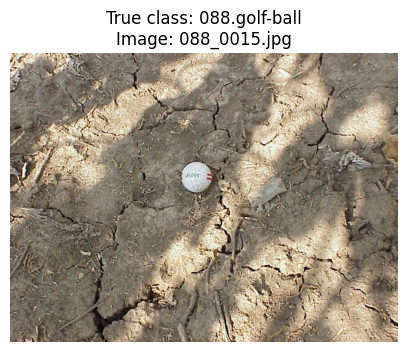

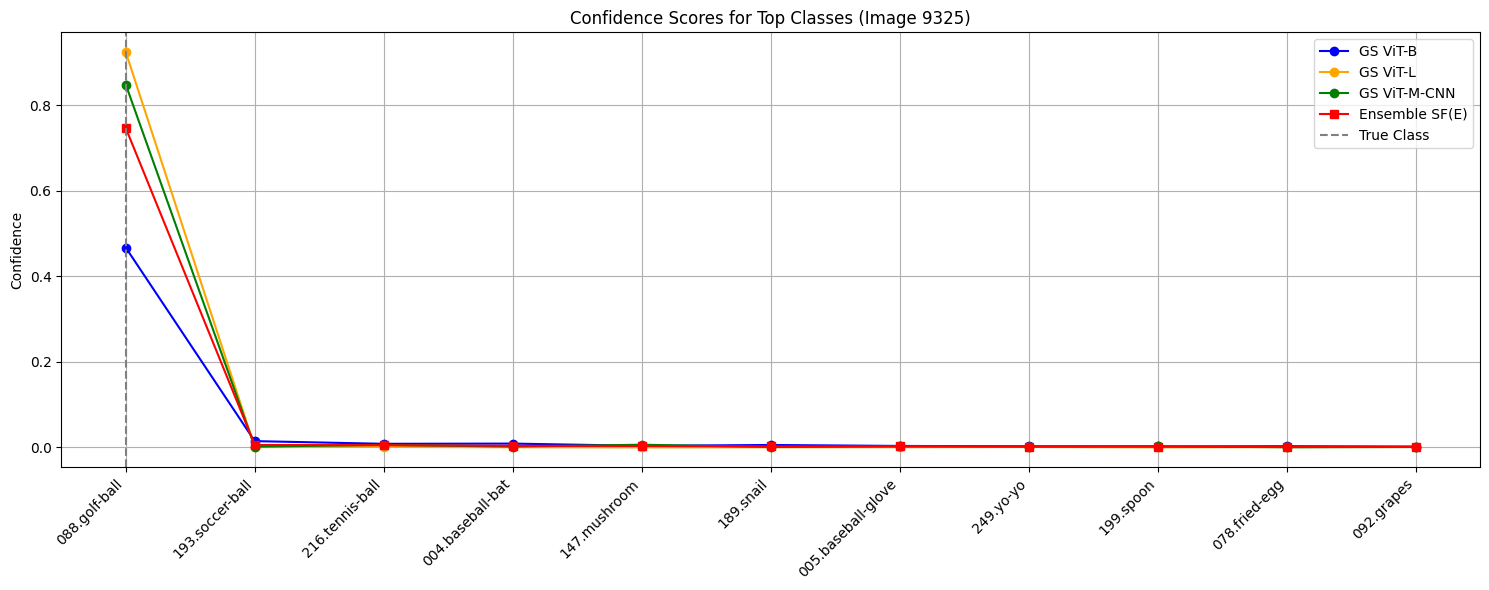


Demo for Image 9325 (Index: 9324):
GS ViT-B Top 5 Predictions:
1. 088.golf-ball: 0.4673
2. 193.soccer-ball: 0.0147
3. 004.baseball-bat: 0.0090
4. 216.tennis-ball: 0.0084
5. 189.snail: 0.0057

GS ViT-L Top 5 Predictions:
1. 088.golf-ball: 0.9245
2. 216.tennis-ball: 0.0012
3. 249.yo-yo: 0.0010
4. 092.grapes: 0.0009
5. 078.fried-egg: 0.0008

GS ViT-M-CNN Top 5 Predictions:
1. 088.golf-ball: 0.8486
2. 147.mushroom: 0.0063
3. 216.tennis-ball: 0.0060
4. 199.spoon: 0.0027
5. 005.baseball-glove: 0.0026

Ensemble SF(E) Top 5 Predictions:
1. 088.golf-ball: 0.7468
2. 193.soccer-ball: 0.0057
3. 216.tennis-ball: 0.0052
4. 004.baseball-bat: 0.0038
5. 147.mushroom: 0.0034

--------------------------------------------------


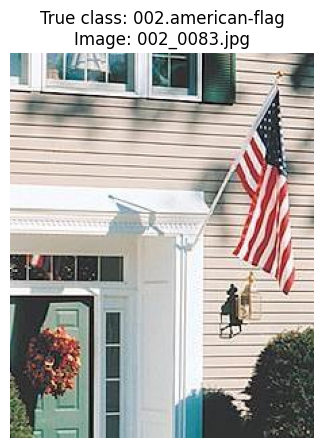

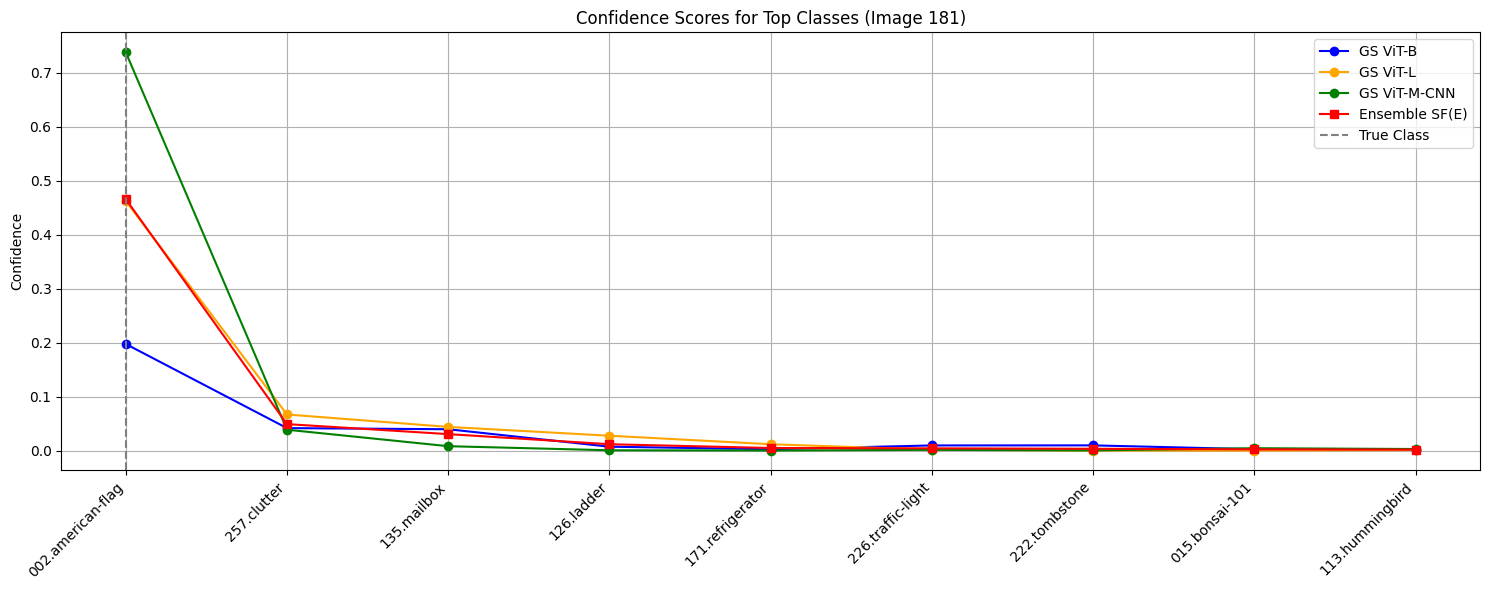


Demo for Image 181 (Index: 180):
GS ViT-B Top 5 Predictions:
1. 002.american-flag: 0.1979
2. 257.clutter: 0.0421
3. 135.mailbox: 0.0401
4. 222.tombstone: 0.0102
5. 226.traffic-light: 0.0101

GS ViT-L Top 5 Predictions:
1. 002.american-flag: 0.4624
2. 257.clutter: 0.0674
3. 135.mailbox: 0.0444
4. 126.ladder: 0.0281
5. 171.refrigerator: 0.0123

GS ViT-M-CNN Top 5 Predictions:
1. 002.american-flag: 0.7378
2. 257.clutter: 0.0392
3. 135.mailbox: 0.0087
4. 015.bonsai-101: 0.0050
5. 113.hummingbird: 0.0035

Ensemble SF(E) Top 5 Predictions:
1. 002.american-flag: 0.4660
2. 257.clutter: 0.0496
3. 135.mailbox: 0.0310
4. 126.ladder: 0.0123
5. 171.refrigerator: 0.0053

--------------------------------------------------


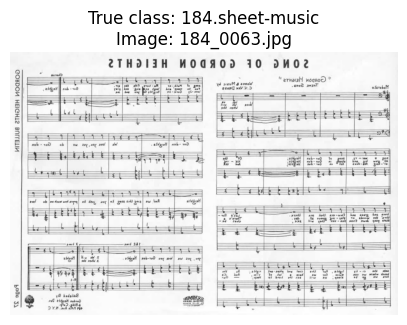

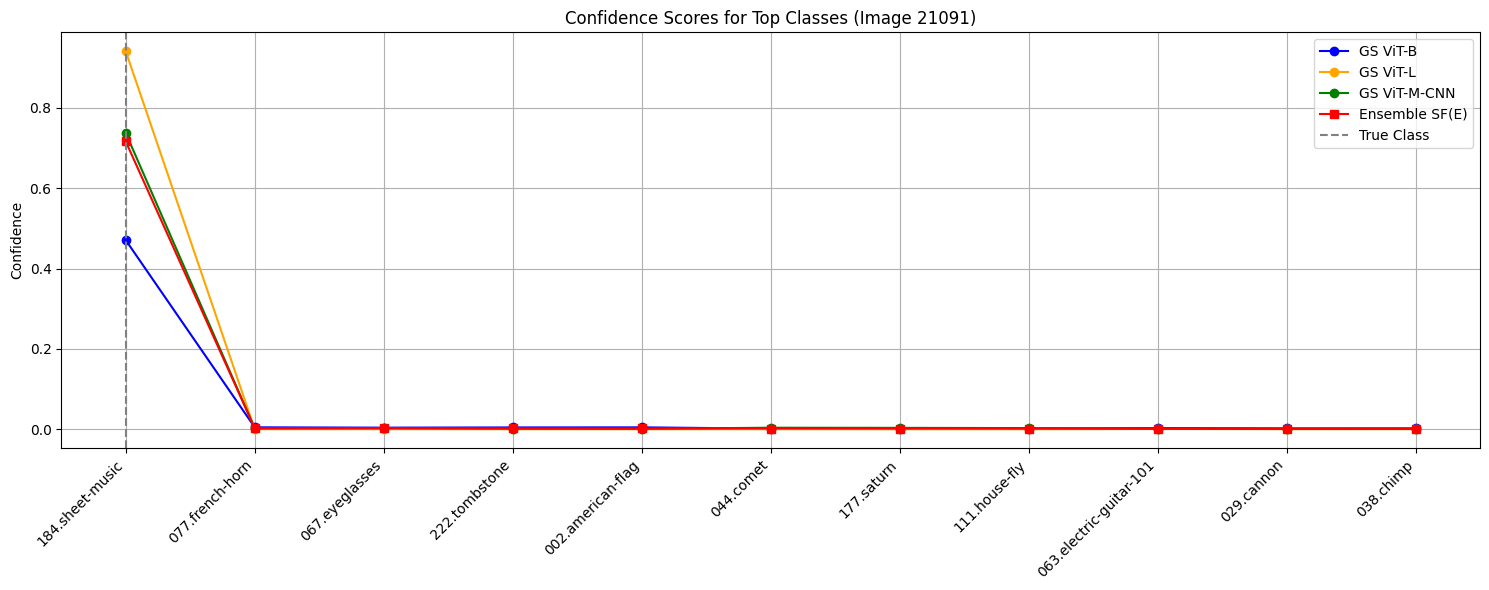


Demo for Image 21091 (Index: 21090):
GS ViT-B Top 5 Predictions:
1. 184.sheet-music: 0.4708
2. 077.french-horn: 0.0050
3. 002.american-flag: 0.0050
4. 222.tombstone: 0.0048
5. 067.eyeglasses: 0.0042

GS ViT-L Top 5 Predictions:
1. 184.sheet-music: 0.9409
2. 063.electric-guitar-101: 0.0009
3. 067.eyeglasses: 0.0005
4. 029.cannon: 0.0005
5. 038.chimp: 0.0005

GS ViT-M-CNN Top 5 Predictions:
1. 184.sheet-music: 0.7373
2. 044.comet: 0.0041
3. 177.saturn: 0.0037
4. 111.house-fly: 0.0032
5. 067.eyeglasses: 0.0030

Ensemble SF(E) Top 5 Predictions:
1. 184.sheet-music: 0.7163
2. 077.french-horn: 0.0026
3. 067.eyeglasses: 0.0026
4. 222.tombstone: 0.0023
5. 172.revolver-101: 0.0023

--------------------------------------------------


In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from transformers import ViTForImageClassification, ViTImageProcessor, ViTModel, ViTConfig
from torchvision import transforms
from torchvision.models import efficientnet_b0
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import kagglehub

DATASET_PATH = os.path.join(kagglehub.dataset_download("jessicali9530/caltech256"), "256_ObjectCategories")
MODEL_PATHS = {
    'ViT-B': './GS-ViT-B.pth',
    'ViT-L': './GS-ViT-L.pth',
    'ViT-M-CNN': './GS-ViT-M-CNN.pth'
}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 257
NUM_IMAGES = 3

class ModelOutput:
    def __init__(self, logits):
        self.logits = logits

class HybridModel(nn.Module):
    def __init__(self, num_classes=257, feature_dim=1280, hidden_size=896):
        super().__init__()
        self.cnn = efficientnet_b0(pretrained=True).features
        self.dropout_cnn = nn.Dropout(0.3)
        self.feature_dim = feature_dim
        config_vit = ViTConfig(
            hidden_size=hidden_size,
            num_hidden_layers=18,
            num_attention_heads=14,
            intermediate_size=3584,
            image_size=224,
            patch_size=16,
            num_channels=3,
            hidden_dropout_prob=0.35,
            attention_probs_dropout_prob=0.35
        )
        self.vit = ViTModel(config_vit)
        self.projection = nn.Linear(feature_dim, hidden_size)
        self.dropout_proj = nn.Dropout(0.3)
        num_patches = 49
        self.positional_embeddings = nn.Parameter(torch.zeros(1, num_patches + 1, hidden_size))
        nn.init.normal_(self.positional_embeddings, std=0.02)
        self.dropout = nn.Dropout(0.35)
        self.ln = nn.LayerNorm(hidden_size)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, pixel_values):
        features = self.cnn(pixel_values)
        features = self.dropout_cnn(features)
        batch_size = features.size(0)
        if features.size(2) != 7 or features.size(3) != 7:
            raise ValueError(f"CNN output spatial dimensions {features.size()[2:]} must be 7x7")
        features = features.view(batch_size, self.feature_dim, -1).permute(0, 2, 1)
        projected_features = self.projection(features)
        projected_features = self.dropout_proj(projected_features)
        cls_token = self.vit.embeddings.cls_token.expand(batch_size, -1, -1)
        embeddings = torch.cat([cls_token, projected_features], dim=1)
        embeddings = embeddings + self.positional_embeddings
        encoder_outputs = self.vit.encoder(embeddings)
        cls_output = encoder_outputs.last_hidden_state[:, 0, :]
        cls_output = self.ln(cls_output)
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return ModelOutput(logits=logits)

class Caltech256Dataset:
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.classes = sorted(os.listdir(root_dir))
        self.classes = [c for c in self.classes if os.path.isdir(os.path.join(root_dir, c))]
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.images = []
        self.labels = []
        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            for img_name in os.listdir(cls_dir):
                if img_name.endswith(('.jpg', '.jpeg', '.png')):
                    self.images.append(os.path.join(cls_dir, img_name))
                    self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.images)

    def get_item(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        return image, label, img_path

def preprocess_image(image, processor):
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
    ])
    pixel_values = transform(image).unsqueeze(0)
    return pixel_values

def load_model(model_name, model_type, num_classes, soup_path):
    if model_type == 'hybrid':
        model = HybridModel(num_classes=num_classes)
    else:
        model = ViTForImageClassification.from_pretrained(
            model_name,
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )
    try:
        state_dict = torch.load(soup_path, map_location='cpu')['model_state_dict']
        model.load_state_dict(state_dict, strict=False)
    except Exception as e:
        raise RuntimeError(f"Failed to load state dict from {soup_path}: {e}")
    return model

def print_top5(model_name, probs, true_label, idx_to_class):
    top5_idx = np.argsort(probs)[-5:][::-1]
    print(f"{model_name} Top 5 Predictions:")
    for i, idx in enumerate(top5_idx, 1):
        class_name = idx_to_class[idx]
        conf = probs[idx]
        print(f"{i}. {class_name}: {conf:.4f}")
    if true_label not in top5_idx:
        true_conf = probs[true_label]
        true_class_name = idx_to_class[true_label]
        print(f"(True class: {true_class_name}, confidence: {true_conf:.4f})")
    print()

def demo(dataset_path, model_paths, device, num_images):
    processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
    
    dataset = Caltech256Dataset(dataset_path)
    classes = dataset.classes
    idx_to_class = {i: cls for i, cls in enumerate(classes)}
    
    models = {}
    models_config = [
        {'name': 'ViT-B', 'model_name': "google/vit-base-patch16-224-in21k", 'type': 'vit', 'soup_path': model_paths['ViT-B']},
        {'name': 'ViT-L', 'model_name': "google/vit-large-patch16-224-in21k", 'type': 'vit', 'soup_path': model_paths['ViT-L']},
        {'name': 'ViT-M-CNN', 'model_name': None, 'type': 'hybrid', 'soup_path': model_paths['ViT-M-CNN']}
    ]
    for config in models_config:
        model = load_model(config['model_name'], config['type'], NUM_CLASSES, config['soup_path'])
        model.to(device)
        model.eval()
        models[config['name']] = model
    
    random_indices = random.sample(range(len(dataset)), num_images)
    
    for idx in random_indices:
        image, true_label, img_path = dataset.get_item(idx)
        true_class = idx_to_class[true_label]
        pixel_values = preprocess_image(image, processor).to(device)
        
        probs = {}
        with torch.no_grad():
            for model_name, model in models.items():
                outputs = model(pixel_values)
                logits = outputs.logits
                prob = F.softmax(logits, dim=1).cpu().numpy()[0]
                probs[model_name] = prob
        
        ensemble_probs = np.mean([probs['ViT-B'], probs['ViT-L'], probs['ViT-M-CNN']], axis=0)
        
        top5_vitb = np.argsort(probs['ViT-B'])[-5:][::-1]
        top5_vitl = np.argsort(probs['ViT-L'])[-5:][::-1]
        top5_vitmcnn = np.argsort(probs['ViT-M-CNN'])[-5:][::-1]
        
        selected_classes = list(set(list(top5_vitb) + list(top5_vitl) + list(top5_vitmcnn) + [true_label]))
        
        sorted_classes = sorted(selected_classes, key=lambda x: ensemble_probs[x], reverse=True)
        
        selected_class_names = [idx_to_class[i] for i in sorted_classes]
        
        plt.figure(figsize=(5, 5))
        plt.imshow(image)
        plt.title(f"True class: {true_class}\nImage: {os.path.basename(img_path)}")
        plt.axis('off')
        plt.show()
        
        fig, ax = plt.subplots(figsize=(15, 6))
        x = np.arange(len(sorted_classes))
        
        ax.plot(x, [probs['ViT-B'][i] for i in sorted_classes], label='GS ViT-B', color='blue', marker='o')
        ax.plot(x, [probs['ViT-L'][i] for i in sorted_classes], label='GS ViT-L', color='orange', marker='o')
        ax.plot(x, [probs['ViT-M-CNN'][i] for i in sorted_classes], label='GS ViT-M-CNN', color='green', marker='o')
        ax.plot(x, [ensemble_probs[i] for i in sorted_classes], label='Ensemble SF(E)', color='red', marker='s')
        
        true_class_pos = sorted_classes.index(true_label)
        ax.axvline(x=true_class_pos, color='gray', linestyle='--', label='True Class')
        
        ax.set_xticks(x)
        ax.set_xticklabels(selected_class_names, rotation=45, ha='right', fontsize=10)
        ax.set_ylabel('Confidence')
        ax.set_title(f'Confidence Scores for Top Classes (Image {idx + 1})')
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.show()
        
        print(f"\nDemo for Image {idx + 1} (Index: {idx}):")
        print_top5('GS ViT-B', probs['ViT-B'], true_label, idx_to_class)
        print_top5('GS ViT-L', probs['ViT-L'], true_label, idx_to_class)
        print_top5('GS ViT-M-CNN', probs['ViT-M-CNN'], true_label, idx_to_class)
        print_top5('Ensemble SF(E)', ensemble_probs, true_label, idx_to_class)
        print("-" * 50)
    
    for model in models.values():
        model.to('cpu')
    torch.cuda.empty_cache()

if __name__ == "__main__":
    if not os.path.exists(DATASET_PATH):
        raise FileNotFoundError(f"Dataset path {DATASET_PATH} does not exist")
    for path in MODEL_PATHS.values():
        if not os.path.exists(path):
            raise FileNotFoundError(f"Model weight file {path} does not exist")
    demo(DATASET_PATH, MODEL_PATHS, DEVICE, NUM_IMAGES)

# Best Model Soft Voting (Equal) Plot Generation


In [ ]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import ViTForImageClassification, ViTImageProcessor, ViTModel, ViTConfig
from torchvision import transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np
from torch import nn
from torch.nn import functional as F
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

CHECKPOINT_DIR = './Soup_Saved_5_ViTB'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
SPLIT_FILE = "split_indices.pkl"

class ModelOutput:
    def __init__(self, logits):
        self.logits = logits

class HybridModel(nn.Module):
    def __init__(self, num_classes=257, feature_dim=1280, hidden_size=896):
        super().__init__()
        self.cnn = efficientnet_b0(pretrained=True).features
        self.dropout_cnn = nn.Dropout(0.3)
        self.feature_dim = feature_dim
        config_vit = ViTConfig(
            hidden_size=hidden_size,
            num_hidden_layers=18,
            num_attention_heads=14,
            intermediate_size=3584,
            image_size=224,
            patch_size=16,
            num_channels=3,
            hidden_dropout_prob=0.35,
            attention_probs_dropout_prob=0.35
        )
        self.vit = ViTModel(config_vit)
        self.projection = nn.Linear(feature_dim, hidden_size)
        self.dropout_proj = nn.Dropout(0.3)
        num_patches = 49
        self.positional_embeddings = nn.Parameter(torch.zeros(1, num_patches + 1, hidden_size))
        nn.init.normal_(self.positional_embeddings, std=0.02)
        self.dropout = nn.Dropout(0.35)
        self.ln = nn.LayerNorm(hidden_size)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, pixel_values):
        features = self.cnn(pixel_values)
        features = self.dropout_cnn(features)
        batch_size = features.size(0)
        if features.size(2) != 7 or features.size(3) != 7:
            raise ValueError(f"CNN output spatial dimensions {features.size()[2:]} must be 7x7")
        features = features.view(batch_size, self.feature_dim, -1).permute(0, 2, 1)
        projected_features = self.projection(features)
        projected_features = self.dropout_proj(projected_features)
        cls_token = self.vit.embeddings.cls_token.expand(batch_size, -1, -1)
        embeddings = torch.cat([cls_token, projected_features], dim=1)
        embeddings = embeddings + self.positional_embeddings
        encoder_outputs = self.vit.encoder(embeddings)
        cls_output = encoder_outputs.last_hidden_state[:, 0, :]
        cls_output = self.ln(cls_output)
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return ModelOutput(logits=logits)

class Caltech256Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.images = []
        self.labels = []
        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.endswith(('.jpg', '.jpeg', '.png')):
                        self.images.append(os.path.join(cls_dir, img_name))
                        self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return {"pixel_values": image, "label": torch.tensor(label, dtype=torch.long)}

def load_dataset(root_dir, transform):
    return Caltech256Dataset(root_dir=root_dir, transform=transform)

def split_dataset(dataset, test_size=0.3, val_size=0.5, random_state=11):
    labels = dataset.labels
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, temp_idx = next(sss1.split(np.zeros(len(labels)), labels))
    temp_labels = [labels[i] for i in temp_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    val_idx, test_idx = next(sss2.split(np.zeros(len(temp_labels)), temp_labels))
    val_idx = [temp_idx[i] for i in val_idx]
    test_idx = [temp_idx[i] for i in test_idx]
    return train_idx, val_idx, test_idx

def get_transform(processor):
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
    ])

def get_model(model_name, num_classes, local_model_path=None, model_type='vit'):
    if model_type == 'hybrid':
        print("Initializing ViT-M-CNN Hybrid Model")
        model = HybridModel(num_classes=num_classes)
        return model

    if model_name is None:
        raise ValueError("model_name must be provided for non-hybrid model types")

    print(f"Loading model from local folder or downloading: {model_name}")
    model = ViTForImageClassification.from_pretrained(
        model_name,
        num_labels=num_classes,
        ignore_mismatched_sizes=True
    )
    return model

def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    probs_list = []
    true_labels = []
    with torch.no_grad():
        for batch in data_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels_batch = batch["label"].to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(pixel_values)
                logits = outputs.logits
            prob = F.softmax(logits, dim=1).cpu().numpy()
            probs_list.extend(prob)
            true_labels.extend(labels_batch.cpu().numpy())
    return np.array(probs_list), np.array(true_labels)

def plot_confidence_distributions(confidences_correct, confidences_incorrect, model_name=""):
    plt.figure(figsize=(10, 5))
    plt.hist(confidences_correct, bins=20, alpha=0.5, label='Correct Predictions')
    plt.hist(confidences_incorrect, bins=20, alpha=0.5, label='Incorrect Predictions')
    plt.xlabel('Confidence')
    plt.ylabel('Frequency')
    plt.title(f'Prediction Confidence Distributions ({model_name})')
    plt.legend()
    plt.savefig(os.path.join(CHECKPOINT_DIR, f'confidence_distributions_{model_name}.png'))
    plt.close()

def plot_lowest_f1_scores(f1_per_class, classes, top_m=20, model_name=""):
    lowest_f1_indices = np.argsort(f1_per_class)[:top_m]
    lowest_f1_classes = [classes[i] for i in lowest_f1_indices]
    lowest_f1_scores = f1_per_class[lowest_f1_indices]
    
    plt.figure(figsize=(12, 6))
    plt.bar(range(top_m), lowest_f1_scores)
    plt.xticks(range(top_m), lowest_f1_classes, rotation=90)
    plt.title(f'Top {top_m} Classes with Lowest F1-Scores ({model_name})')
    plt.xlabel('Class')
    plt.ylabel('F1-Score')
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, f'lowest_f1_scores_{model_name}_top_20.png'))
    plt.close()

def plot_confusion_matrix(cm, classes, f1_per_class, top_n=10, model_name=""):
    lowest_f1_indices = np.argsort(f1_per_class)[:top_n]
    sub_cm = cm[lowest_f1_indices, :][:, lowest_f1_indices]
    lowest_f1_classes = [classes[i] for i in lowest_f1_indices]
    
    plt.figure(figsize=(12, 10))
    plt.imshow(sub_cm, cmap='Blues')
    plt.xticks(range(top_n), lowest_f1_classes, rotation=90)
    plt.yticks(range(top_n), lowest_f1_classes)
    plt.colorbar()
    plt.title(f'Confusion Matrix for Top {top_n} Classes with Lowest F1-Scores ({model_name})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, f'confusion_matrix_{model_name}_top_10.png'))
    plt.close()

def main(config):
    torch.manual_seed(config['seed'])
    np.random.seed(config['seed'])

    processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

    transform = get_transform(processor)
    dataset = load_dataset(config['dataset_path'], transform)

    train_idx, val_idx, test_idx = split_dataset(dataset, config['test_size'], config['val_size'], config['seed'])
    test_dataset = torch.utils.data.Subset(dataset, test_idx)
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=config['num_workers'])

    criterion = nn.CrossEntropyLoss()

    models_config = [
        {
            'name': 'ViT-B',
            'model_name': "google/vit-base-patch16-224-in21k",
            'soup_path': './GS-ViT-B.pth',
            'model_type': 'vit'
        },
        {
            'name': 'ViT-L',
            'model_name': "google/vit-large-patch16-224-in21k",
            'soup_path': './GS-ViT-L.pth',
            'model_type': 'vit'
        },
        {
            'name': 'ViT-M-CNN',
            'soup_path': './GS-ViT-M-CNN.pth',
            'model_type': 'hybrid'
        }
    ]

    all_probs = []
    true_labels = None
    for model_config in models_config:
        print(f"\nLoading {model_config['name']} Greedy Soup")
        if not os.path.exists(model_config['soup_path']):
            print(f"Error: Soup file {model_config['soup_path']} not found. Skipping {model_config['name']}.")
            continue
        model = get_model(
            model_config.get('model_name'),
            config['num_classes'],
            model_type=model_config['model_type']
        )
        try:
            state_dict = torch.load(model_config['soup_path'], map_location='cpu')['model_state_dict']
            model.load_state_dict(state_dict, strict=False)
            print(f"Loaded state dict for {model_config['name']} (strict=False)")
        except Exception as e:
            print(f"Error loading state_dict for {model_config['name']}: {e}. Skipping.")
            continue
        model.to(config['device'])
        probs, test_true = evaluate_model(model, test_loader, criterion, config['device'])
        all_probs.append(probs)
        if true_labels is None:
            true_labels = test_true
        model.to('cpu')
        del model
        torch.cuda.empty_cache()

    if not all_probs:
        print("No models were successfully evaluated. Exiting.")
        return

    avg_probs = np.mean(all_probs, axis=0)
    ensemble_preds_soft = np.argmax(avg_probs, axis=1)
    ensemble_accuracy_soft = accuracy_score(true_labels, ensemble_preds_soft)
    ensemble_macro_f1_soft = precision_recall_fscore_support(true_labels, ensemble_preds_soft, average='macro', zero_division=0)[2]
    print(f"Soft Voting Ensemble (Equal Weights) - Accuracy: {ensemble_accuracy_soft:.4f}, Macro F1: {ensemble_macro_f1_soft:.4f}")

    f1_per_class = precision_recall_fscore_support(true_labels, ensemble_preds_soft, average=None, labels=np.arange(config['num_classes']), zero_division=0)[2]
    cm = confusion_matrix(true_labels, ensemble_preds_soft, labels=np.arange(config['num_classes']))
    confidences = np.max(avg_probs, axis=1)
    correct_mask = ensemble_preds_soft == true_labels
    confidences_correct = confidences[correct_mask]
    confidences_incorrect = confidences[~correct_mask]

    plot_confidence_distributions(confidences_correct, confidences_incorrect, model_name="Soft_Voting_Equal")
    plot_lowest_f1_scores(f1_per_class, dataset.classes, top_m=20, model_name="Soft_Voting_Equal")
    plot_confusion_matrix(cm, dataset.classes, f1_per_class, top_n=10, model_name="Soft_Voting_Equal")

    print("\nSummary of Results:")
    results_data = [{
        'Model': 'Soft Voting (Equal Weights)',
        'Test Accuracy': f"{ensemble_accuracy_soft:.4f}",
        'Test Macro F1': f"{ensemble_macro_f1_soft:.4f}"
    }]
    df = pd.DataFrame(results_data)
    print(df.to_string(index=False))

config = {
    'seed': 10,
    'num_classes': 257,
    'dataset_path': os.path.join(kagglehub.dataset_download("jessicali9530/caltech256"), "256_ObjectCategories"),
    'test_size': 0.3,
    'val_size': 0.5,
    'batch_size': 64,
    'num_workers': 0,
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}

if __name__ == "__main__":
    main(config)


Loading ViT-B Greedy Soup
Loading model from local folder or downloading: google/vit-base-patch16-224-in21k


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded state dict for ViT-B (strict=False)

Loading ViT-L Greedy Soup
Loading model from local folder or downloading: google/vit-large-patch16-224-in21k


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-large-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded state dict for ViT-L (strict=False)

Loading ViT-M-CNN Greedy Soup
Initializing ViT-M-CNN Hybrid Model


c:\Users\Dell-G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Dell-G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded state dict for ViT-M-CNN (strict=False)
Soft Voting Ensemble (Equal Weights) - Accuracy: 0.9676, Macro F1: 0.9685

Summary of Results:
                      Model Test Accuracy Test Macro F1
Soft Voting (Equal Weights)        0.9676        0.9685


# Meta Learner EL Code

In [ ]:
import os
import pickle
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import ViTForImageClassification, ViTImageProcessor, ViTModel, ViTConfig
from torchvision import transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
from collections import Counter
from torch import nn
from torch.nn import functional as F
import kagglehub
from scipy.stats import mode
import pandas as pd

CHECKPOINT_DIR = './Soup_Saved_5_ViTB'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
SPLIT_FILE = "split_indices.pkl"
META_LEARNER_DIR = './meta-learner'
os.makedirs(META_LEARNER_DIR, exist_ok=True)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

class ClassBalancedLoss(nn.Module):
    def __init__(self, beta, gamma, reduction='mean'):
        super(ClassBalancedLoss, self).__init__()
        self.beta = beta
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets, samples_per_cls):
        num_classes = logits.size(1)
        effective_num = 1.0 - torch.pow(self.beta, samples_per_cls)
        weights = (1.0 - self.beta) / (effective_num + 1e-8)
        weights = weights / weights.sum() * num_classes
        weights = weights.to(logits.device)
        targets_one_hot = F.one_hot(targets, num_classes=num_classes).float()
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)
        focal_weight = torch.pow(1 - probs, self.gamma)
        cb_loss = -weights.unsqueeze(0) * focal_weight * targets_one_hot * log_probs
        loss = cb_loss.sum(dim=1)
        return loss.mean() if self.reduction == 'mean' else loss.sum()

class ModelOutput:
    def __init__(self, logits):
        self.logits = logits

class HybridModel(nn.Module):
    def __init__(self, num_classes=257, feature_dim=1280, hidden_size=896):
        super().__init__()
        self.cnn = efficientnet_b0(pretrained=True).features
        self.dropout_cnn = nn.Dropout(0.3)
        self.feature_dim = feature_dim
        
        config_vit = ViTConfig(
            hidden_size=hidden_size,
            num_hidden_layers=18,
            num_attention_heads=14,
            intermediate_size=3584,
            image_size=224,
            patch_size=16,
            num_channels=3,
            hidden_dropout_prob=0.35,
            attention_probs_dropout_prob=0.35
        )
        self.vit = ViTModel(config_vit)
        
        self.projection = nn.Linear(feature_dim, hidden_size)
        self.dropout_proj = nn.Dropout(0.3)
        num_patches = 49  # (224/16)^2
        self.positional_embeddings = nn.Parameter(torch.zeros(1, num_patches + 1, hidden_size))
        nn.init.normal_(self.positional_embeddings, std=0.02)
        self.dropout = nn.Dropout(0.35)
        self.ln = nn.LayerNorm(hidden_size)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, pixel_values):
        features = self.cnn(pixel_values)
        features = self.dropout_cnn(features)
        batch_size = features.size(0)
        if features.size(2) != 7 or features.size(3) != 7:
            raise ValueError(f"CNN output spatial dimensions {features.size()[2:]} must be 7x7")
        features = features.view(batch_size, self.feature_dim, -1).permute(0, 2, 1)
        projected_features = self.projection(features)
        projected_features = self.dropout_proj(projected_features)
        cls_token = self.vit.embeddings.cls_token.expand(batch_size, -1, -1)
        embeddings = torch.cat([cls_token, projected_features], dim=1)
        embeddings = embeddings + self.positional_embeddings
        encoder_outputs = self.vit.encoder(embeddings)
        cls_output = encoder_outputs.last_hidden_state[:, 0, :]
        cls_output = self.ln(cls_output)
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return ModelOutput(logits=logits)

class Caltech256Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.images = []
        self.labels = []
        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.endswith(('.jpg', '.jpeg', '.png')):
                        self.images.append(os.path.join(cls_dir, img_name))
                        self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return {"pixel_values": image, "label": torch.tensor(label, dtype=torch.long)}

class MetaLearner(nn.Module):
    def __init__(self, num_models, num_classes, hidden_dim=256):
        super(MetaLearner, self).__init__()
        self.input_dim = num_models * num_classes
        self.fc1 = nn.Linear(self.input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, hidden_dim // 4)
        self.fc4 = nn.Linear(hidden_dim // 4, num_classes)
        self.dropout = nn.Dropout(0.4)
        self.relu = nn.ReLU()
        self.batch_norm1 = nn.BatchNorm1d(hidden_dim)
        self.batch_norm2 = nn.BatchNorm1d(hidden_dim // 2)
        self.batch_norm3 = nn.BatchNorm1d(hidden_dim // 4)

    def forward(self, model_probs):
        batch_size = model_probs.size(0)
        x = model_probs.view(batch_size, -1)
        x = self.relu(self.batch_norm1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.batch_norm2(self.fc2(x)))
        x = self.dropout(x)
        x = self.relu(self.batch_norm3(self.fc3(x)))
        x = self.dropout(x)
        logits = self.fc4(x)
        return logits

def load_dataset(root_dir, transform):
    return Caltech256Dataset(root_dir=root_dir, transform=transform)

def split_dataset(dataset, test_size=0.3, val_size=0.5, random_state=11):
    labels = dataset.labels
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, temp_idx = next(sss1.split(np.zeros(len(labels)), labels))
    temp_labels = [labels[i] for i in temp_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    val_idx, test_idx = next(sss2.split(np.zeros(len(temp_labels)), temp_labels))
    val_idx = [temp_idx[i] for i in val_idx]
    test_idx = [temp_idx[i] for i in test_idx]
    return train_idx, val_idx, test_idx

def save_split_indices(train_idx, val_idx, test_idx, file_path=SPLIT_FILE):
    with open(file_path, "wb") as f:
        pickle.dump((train_idx, val_idx, test_idx), f)
    print(f"Split indices saved to {file_path}")

def load_split_indices(file_path=SPLIT_FILE):
    with open(file_path, "rb") as f:
        train_idx, val_idx, test_idx = pickle.load(f)
    print(f"Loaded split indices from {file_path}")
    return train_idx, val_idx, test_idx

def get_transform(processor):
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
    ])

def get_model(model_name, num_classes, freeze_layers=0, local_model_path=None, model_type='vit'):
    if model_type == 'hybrid':
        print("Initializing ViT-M-CNN Hybrid Model")
        model = HybridModel(num_classes=num_classes)
        return model

    has_valid_model_files = False
    if local_model_path and os.path.exists(local_model_path):
        expected_files = ['pytorch_model.bin', 'model.safetensors', 'config.json']
        has_valid_model_files = any(os.path.exists(os.path.join(local_model_path, f)) for f in expected_files)
        if has_valid_model_files:
            print(f"Loading model from local folder: {local_model_path}")
            try:
                model = ViTForImageClassification.from_pretrained(
                    local_model_path,
                    num_labels=num_classes,
                    ignore_mismatched_sizes=True
                )
                return model
            except Exception as e:
                print(f"Failed to load model from {local_model_path}: {e}. Falling back to downloading.")

    print(f"Downloading model {model_name} from Hugging Face...")
    model = ViTForImageClassification.from_pretrained(
        model_name,
        num_labels=num_classes,
        ignore_mismatched_sizes=True
    )
    if local_model_path and not has_valid_model_files:
        os.makedirs(local_model_path, exist_ok=True)
        model.save_pretrained(local_model_path)
        print(f"Model saved to {local_model_path}")

    if freeze_layers > 0:
        num_layers = len(model.vit.encoder.layer)
        freeze_layers = min(freeze_layers, num_layers)
        for i in range(freeze_layers):
            for param in model.vit.encoder.layer[i].parameters():
                param.requires_grad = False
        print(f"Froze the first {freeze_layers} layers of the ViT encoder.")
    return model

def get_loss_function(loss_type, **kwargs):
    if loss_type == 'focal':
        return FocalLoss(gamma=kwargs.get('gamma', 2.0))
    elif loss_type == 'class_balanced':
        return ClassBalancedLoss(beta=kwargs.get('beta', 0.9999), gamma=kwargs.get('gamma', 2.0))
    else:
        raise ValueError("Unsupported loss type")

def evaluate_model(model, data_loader, criterion, device, samples_per_cls=None):
    model.eval()
    total_loss = 0
    preds = []
    probs_list = []
    true_labels = []
    with torch.no_grad():
        for batch in data_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels_batch = batch["label"].to(device)
            if labels_batch.max() >= model.classifier.out_features:
                raise ValueError(f"Label {labels_batch.max().item()} exceeds model classes {model.classifier.out_features}")
            with torch.amp.autocast('cuda'):
                outputs = model(pixel_values)
                logits = outputs.logits
                loss = criterion(logits, labels_batch, samples_per_cls) if isinstance(criterion, ClassBalancedLoss) else criterion(logits, labels_batch)
            total_loss += loss.item()
            pred_labels = logits.argmax(dim=-1).cpu().numpy()
            prob = F.softmax(logits, dim=1).cpu().numpy()
            preds.extend(pred_labels)
            probs_list.extend(prob)
            true_labels.extend(labels_batch.cpu().numpy())
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(true_labels, preds)
    macro_f1 = precision_recall_fscore_support(true_labels, preds, average='macro', zero_division=0)[2]
    return avg_loss, accuracy, macro_f1, np.array(preds), np.array(probs_list), np.array(true_labels)

def train_meta_learner(meta_learner, probs_list, true_labels, device, num_epochs=50, lr=0.001, patience=10):
    meta_learner.to(device)
    optimizer = torch.optim.Adam(meta_learner.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
    criterion = nn.CrossEntropyLoss()
    
    probs_tensor = torch.tensor(np.stack(probs_list, axis=1), dtype=torch.float32)
    labels_tensor = torch.tensor(true_labels, dtype=torch.long)
    
    val_size = 0.2
    indices = np.arange(len(true_labels))
    np.random.shuffle(indices)
    split = int(val_size * len(indices))
    train_idx, val_idx = indices[split:], indices[:split]
    
    train_probs = probs_tensor[train_idx]
    train_labels = labels_tensor[train_idx]
    val_probs = probs_tensor[val_idx]
    val_labels = labels_tensor[val_idx]
    
    train_dataset = torch.utils.data.TensorDataset(train_probs, train_labels)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_dataset = torch.utils.data.TensorDataset(val_probs, val_labels)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
    
    best_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    loss_history = []
    
    for epoch in range(num_epochs):
        meta_learner.train()
        total_train_loss = 0
        for probs, labels in train_loader:
            probs, labels = probs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = meta_learner(probs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)
        
        meta_learner.eval()
        total_val_loss = 0
        with torch.no_grad():
            for probs, labels in val_loader:
                probs, labels = probs.to(device), labels.to(device)
                outputs = meta_learner(probs)
                loss = criterion(outputs, labels)
                total_val_loss += loss.item()
        avg_val_loss = total_val_loss / len(val_loader)
        
        print(f"Meta-Learner Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        
        loss_history.append({
            'Epoch': epoch + 1,
            'Train_Loss': avg_train_loss,
            'Val_Loss': avg_val_loss
        })
        
        scheduler.step(avg_val_loss)
        
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_model_state = meta_learner.state_dict()
            save_path = os.path.join(META_LEARNER_DIR, 'meta_learner_best.pth')
            torch.save({'model_state_dict': best_model_state}, save_path)
            print(f"Saved best meta-learner model to {save_path}")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs")
                break
    
    loss_df = pd.DataFrame(loss_history)
    loss_csv_path = os.path.join(META_LEARNER_DIR, 'meta_learner_losses.csv')
    loss_df.to_csv(loss_csv_path, index=False)
    print(f"Saved meta-learner loss history to {loss_csv_path}")
    
    if best_model_state is not None:
        meta_learner.load_state_dict(best_model_state)
    
    return meta_learner

def evaluate_meta_learner(meta_learner, probs_list, true_labels, device):
    meta_learner.eval()
    probs_tensor = torch.tensor(np.stack(probs_list, axis=1), dtype=torch.float32).to(device)
    labels_tensor = torch.tensor(true_labels, dtype=torch.long).to(device)
    
    with torch.no_grad():
        logits = meta_learner(probs_tensor)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        probs = F.softmax(logits, dim=1).cpu().numpy()
    
    accuracy = accuracy_score(true_labels, preds)
    macro_f1 = precision_recall_fscore_support(true_labels, preds, average='macro', zero_division=0)[2]
    return accuracy, macro_f1, preds, probs

def main(config):
    torch.manual_seed(config['seed'])
    np.random.seed(config['seed'])
    torch.backends.cudnn.deterministic = True

    default_model_name = "google/vit-base-patch16-224-in21k"
    default_local_path = "./local_model/vit-base-patch16-224-in21k"
    if os.path.exists(default_local_path):
        print(f"Loading processor from local folder: {default_local_path}")
        try:
            processor = ViTImageProcessor.from_pretrained(default_local_path)
        except Exception as e:
            print(f"Failed to load processor from {default_local_path}: {e}. Downloading from Hugging Face...")
            processor = ViTImageProcessor.from_pretrained(default_model_name)
            os.makedirs(default_local_path, exist_ok=True)
            processor.save_pretrained(default_local_path)
            print(f"Processor saved to {default_local_path}")
    else:
        print("Downloading processor from Hugging Face...")
        processor = ViTImageProcessor.from_pretrained(default_model_name)
        os.makedirs(default_local_path, exist_ok=True)
        processor.save_pretrained(default_local_path)
        print(f"Processor saved to {default_local_path}")

    transform = get_transform(processor)
    dataset = load_dataset(config['dataset_path'], transform)
    print(f"Number of classes in dataset: {len(dataset.classes)}")
    if max(dataset.labels) >= config['num_classes']:
        config['num_classes'] = len(dataset.classes)
        print(f"Adjusted num_classes to {config['num_classes']} to match dataset")

    if os.path.exists(SPLIT_FILE):
        train_idx, val_idx, test_idx = load_split_indices(SPLIT_FILE)
    else:
        train_idx, val_idx, test_idx = split_dataset(dataset, config['test_size'], config['val_size'], config['seed'])
        save_split_indices(train_idx, val_idx, test_idx, SPLIT_FILE)

    val_dataset = torch.utils.data.Subset(dataset, val_idx)
    test_dataset = torch.utils.data.Subset(dataset, test_idx)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=config['num_workers'])
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=config['num_workers'])

    if config['loss_type'] == 'class_balanced':
        train_labels = [dataset.labels[i] for i in train_idx]
        samples_per_cls = torch.zeros(config['num_classes'])
        for i, count in Counter(train_labels).items():
            samples_per_cls[i] = count
        criterion = get_loss_function(config['loss_type'], beta=config['beta'], gamma=config['gamma'])
    else:
        criterion = get_loss_function(config['loss_type'], gamma=config['gamma'])
        samples_per_cls = None

    models_config = [
        {
            'name': 'ViT-B',
            'model_name': "google/vit-base-patch16-224-in21k",
            'local_model_path': "./local_model/vit-base-patch16-224-in21k",
            'soup_path': './GS-ViT-B.pth',
            'model_type': 'vit'
        },
        {
            'name': 'ViT-L',
            'model_name': "google/vit-large-patch16-224-in21k",
            'local_model_path': "./local_model/vit-large-patch16-224-in21k",
            'soup_path': './GS-ViT-L.pth',
            'model_type': 'vit'
        },
        {
            'name': 'ViT-M-CNN',
            'model_name': None,
            'local_model_path': None,
            'soup_path': './GS-ViT-M-CNN.pth',
            'model_type': 'hybrid'
        }
    ]

    individual_results = []
    val_probs_all = []
    val_true_all = None
    for model_config in models_config:
        print(f"\nEvaluating {model_config['name']} Greedy Soup")
        if not os.path.exists(model_config['soup_path']):
            print(f"Error: Soup file {model_config['soup_path']} not found. Skipping {model_config['name']}.")
            continue

        model = get_model(
            model_config['model_name'],
            config['num_classes'],
            freeze_layers=0,
            local_model_path=model_config['local_model_path'],
            model_type=model_config['model_type']
        )
        try:
            state_dict = torch.load(model_config['soup_path'], map_location='cpu')['model_state_dict']
            model.load_state_dict(state_dict, strict=False)
            print(f"Loaded state dict for {model_config['name']} (strict=False)")
        except Exception as e:
            print(f"Error loading state_dict for {model_config['name']}: {e}. Skipping.")
            continue

        model.to(config['device'])

        val_loss, val_accuracy, val_macro_f1, val_preds, val_probs, val_true = evaluate_model(
            model, val_loader, criterion, config['device'], samples_per_cls
        )
        print(f"{model_config['name']} Validation - Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}, Macro F1: {val_macro_f1:.4f}")

        test_loss, test_accuracy, test_macro_f1, test_preds, test_probs, test_true = evaluate_model(
            model, test_loader, criterion, config['device'], samples_per_cls
        )
        print(f"{model_config['name']} Test - Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.4f}, Macro F1: {test_macro_f1:.4f}")

        individual_results.append({
            'name': model_config['name'],
            'val_accuracy': val_accuracy,
            'val_macro_f1': val_macro_f1,
            'test_accuracy': test_accuracy,
            'test_macro_f1': test_macro_f1,
            'val_probs': val_probs,
            'test_probs': test_probs,
            'test_true': test_true
        })

        val_probs_all.append(val_probs)
        if val_true_all is None:
            val_true_all = val_true

        model.to('cpu')
        del model
        torch.cuda.empty_cache()

    if not individual_results:
        print("No models were successfully evaluated. Exiting.")
        return

    print("\nTraining Meta-Learner")
    meta_learner = MetaLearner(
        num_models=len(individual_results),
        num_classes=config['num_classes'],
        hidden_dim=256
    )
    meta_learner = train_meta_learner(
        meta_learner,
        val_probs_all,
        val_true_all,
        config['device'],
        num_epochs=50,
        lr=0.001,
        patience=10
    )

    print("\nEvaluating Meta-Learner on Test Set")
    test_probs_all = [res['test_probs'] for res in individual_results]
    true_labels = individual_results[0]['test_true']
    meta_accuracy, meta_macro_f1, meta_preds, meta_probs = evaluate_meta_learner(
        meta_learner,
        test_probs_all,
        true_labels,
        config['device']
    )
    print(f"Meta-Learner Ensemble - Accuracy: {meta_accuracy:.4f}, Macro F1: {meta_macro_f1:.4f}")

    print("\nSummary of Results:")
    results_data = []
    for res in individual_results:
        results_data.append({
            'Model': res['name'],
            'Val Accuracy': f"{res['val_accuracy']:.4f}",
            'Val Macro F1': f"{res['val_macro_f1']:.4f}",
            'Test Accuracy': f"{res['test_accuracy']:.4f}",
            'Test Macro F1': f"{res['test_macro_f1']:.4f}"
        })
    results_data.append({
        'Model': 'Meta-Learner Ensemble',
        'Val Accuracy': '-',
        'Val Macro F1': '-',
        'Test Accuracy': f"{meta_accuracy:.4f}",
        'Test Macro F1': f"{meta_macro_f1:.4f}"
    })

    df = pd.DataFrame(results_data)
    print(df.to_string(index=False))

config = {
    'seed': 10,
    'num_classes': 257,
    'dataset_path': os.path.join(kagglehub.dataset_download("jessicali9530/caltech256"), "256_ObjectCategories"),
    'test_size': 0.3,
    'val_size': 0.5,
    'batch_size': 64,
    'num_workers': 0,
    'loss_type': 'focal',
    'beta': 0.9999,
    'gamma': 2.0,
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}

if __name__ == "__main__":
    main(config)

c:\Users\Dell-G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading processor from local folder: ./local_model/vit-base-patch16-224-in21k
Number of classes in dataset: 257
Loaded split indices from split_indices.pkl

Evaluating ViT-B Greedy Soup
Loading model from local folder: ./local_model/vit-base-patch16-224-in21k
Loaded state dict for ViT-B (strict=False)
ViT-B Validation - Loss: 0.5055, Accuracy: 0.9314, Macro F1: 0.9295
ViT-B Test - Loss: 0.4913, Accuracy: 0.9371, Macro F1: 0.9372

Evaluating ViT-L Greedy Soup
Loading model from local folder: ./local_model/vit-large-patch16-224-in21k
Loaded state dict for ViT-L (strict=False)
ViT-L Validation - Loss: 0.2301, Accuracy: 0.9418, Macro F1: 0.9425
ViT-L Test - Loss: 0.2136, Accuracy: 0.9451, Macro F1: 0.9471

Evaluating ViT-M-CNN Greedy Soup
Initializing ViT-M-CNN Hybrid Model


c:\Users\Dell-G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Dell-G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded state dict for ViT-M-CNN (strict=False)
ViT-M-CNN Validation - Loss: 0.3998, Accuracy: 0.9090, Macro F1: 0.9098
ViT-M-CNN Test - Loss: 0.3729, Accuracy: 0.9183, Macro F1: 0.9181

Training Meta-Learner


c:\Users\Dell-G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Meta-Learner Epoch 1/50, Train Loss: 5.0829, Val Loss: 4.9214
Saved best meta-learner model to ./meta-learner\meta_learner_best.pth
Meta-Learner Epoch 2/50, Train Loss: 4.2192, Val Loss: 3.7838
Saved best meta-learner model to ./meta-learner\meta_learner_best.pth
Meta-Learner Epoch 3/50, Train Loss: 3.6774, Val Loss: 3.2043
Saved best meta-learner model to ./meta-learner\meta_learner_best.pth
Meta-Learner Epoch 4/50, Train Loss: 3.1896, Val Loss: 2.6973
Saved best meta-learner model to ./meta-learner\meta_learner_best.pth
Meta-Learner Epoch 5/50, Train Loss: 2.7418, Val Loss: 2.2099
Saved best meta-learner model to ./meta-learner\meta_learner_best.pth
Meta-Learner Epoch 6/50, Train Loss: 2.3495, Val Loss: 1.7145
Saved best meta-learner model to ./meta-learner\meta_learner_best.pth
Meta-Learner Epoch 7/50, Train Loss: 2.0445, Val Loss: 1.2653
Saved best meta-learner model to ./meta-learner\meta_learner_best.pth
Meta-Learner Epoch 8/50, Train Loss: 1.7595, Val Loss: 0.9760
Saved best met

# DRL(PPO) EL (Was Discarded for Overfitting on Training Set)

In [ ]:
import os
import pickle
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import ViTForImageClassification, ViTImageProcessor, ViTModel, ViTConfig
from torchvision import transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
from torch import nn
from torch.nn import functional as F
import kagglehub
import pandas as pd
from torch.distributions import Normal

CHECKPOINT_DIR = './Soup_Saved_5_ViTB'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
SPLIT_FILE = "split_indices.pkl"
DRL_AGENT_DIR = './drl-agent'
os.makedirs(DRL_AGENT_DIR, exist_ok=True)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

class ModelOutput:
    def __init__(self, logits):
        self.logits = logits

class HybridModel(nn.Module):
    def __init__(self, num_classes=257, feature_dim=1280, hidden_size=896):
        super().__init__()
        self.cnn = efficientnet_b0(pretrained=True).features
        self.dropout_cnn = nn.Dropout(0.3)
        self.feature_dim = feature_dim
        config_vit = ViTConfig(
            hidden_size=hidden_size,
            num_hidden_layers=18,
            num_attention_heads=14,
            intermediate_size=3584,
            image_size=224,
            patch_size=16,
            num_channels=3,
            hidden_dropout_prob=0.35,
            attention_probs_dropout_prob=0.35
        )
        self.vit = ViTModel(config_vit)
        self.projection = nn.Linear(feature_dim, hidden_size)
        self.dropout_proj = nn.Dropout(0.3)
        num_patches = 49
        self.positional_embeddings = nn.Parameter(torch.zeros(1, num_patches + 1, hidden_size))
        nn.init.normal_(self.positional_embeddings, std=0.02)
        self.dropout = nn.Dropout(0.35)
        self.ln = nn.LayerNorm(hidden_size)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, pixel_values):
        features = self.cnn(pixel_values)
        features = self.dropout_cnn(features)
        batch_size = features.size(0)
        if features.size(2) != 7 or features.size(3) != 7:
            raise ValueError(f"CNN output spatial dimensions {features.size()[2:]} must be 7x7")
        features = features.view(batch_size, self.feature_dim, -1).permute(0, 2, 1)
        projected_features = self.projection(features)
        projected_features = self.dropout_proj(projected_features)
        cls_token = self.vit.embeddings.cls_token.expand(batch_size, -1, -1)
        embeddings = torch.cat([cls_token, projected_features], dim=1)
        embeddings = embeddings + self.positional_embeddings
        encoder_outputs = self.vit.encoder(embeddings)
        cls_output = encoder_outputs.last_hidden_state[:, 0, :]
        cls_output = self.ln(cls_output)
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return ModelOutput(logits=logits)

class Caltech256Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.images = []
        self.labels = []
        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.endswith(('.jpg', '.jpeg', '.png')):
                        self.images.append(os.path.join(cls_dir, img_name))
                        self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return {"pixel_values": image, "label": torch.tensor(label, dtype=torch.long)}

class PPOPolicy(nn.Module):
    def __init__(self, feature_dim, num_models, hidden_dim=256):
        super(PPOPolicy, self).__init__()
        self.shared = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.actor_mean = nn.Linear(hidden_dim, num_models)
        self.actor_logstd = nn.Parameter(torch.zeros(num_models))
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, state):
        x = self.shared(state)
        mean = self.actor_mean(x)
        logstd = self.actor_logstd
        std = torch.exp(logstd)
        dist = Normal(mean, std)
        value = self.critic(x)
        return dist, value

def load_split_indices(file_path=SPLIT_FILE):
    with open(file_path, "rb") as f:
        train_idx, val_idx, test_idx = pickle.load(f)
    print(f"Loaded split indices from {file_path}")
    return train_idx, val_idx, test_idx

def get_transform(processor):
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
    ])

def get_model(model_name, num_classes, local_model_path=None, model_type='vit'):
    if model_type == 'hybrid':
        print("Initializing ViT-M-CNN Hybrid Model")
        return HybridModel(num_classes=num_classes)
    print(f"Loading model from local folder: {local_model_path}")
    model = ViTForImageClassification.from_pretrained(
        local_model_path,
        num_labels=num_classes,
        ignore_mismatched_sizes=True
    )
    return model

def evaluate_model(model, data_loader, criterion, device, feature_extractor=None):
    model.eval()
    total_loss = 0
    preds = []
    probs_list = []
    true_labels = []
    features_list = []
    with torch.no_grad():
        for batch in data_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels_batch = batch["label"].to(device)
            if labels_batch.max() >= model.classifier.out_features:
                raise ValueError(f"Label {labels_batch.max().item()} exceeds model classes {model.classifier.out_features}")
            with torch.amp.autocast('cuda'):
                outputs = model(pixel_values)
                logits = outputs.logits
                loss = criterion(logits, labels_batch)
                if feature_extractor is not None:
                    feature_outputs = feature_extractor(pixel_values)
                    cls_features = feature_outputs.last_hidden_state[:, 0, :]
                    features_list.append(cls_features.cpu().numpy())
            total_loss += loss.item()
            pred_labels = logits.argmax(dim=-1).cpu().numpy()
            prob = F.softmax(logits, dim=1).cpu().numpy()
            preds.extend(pred_labels)
            probs_list.extend(prob)
            true_labels.extend(labels_batch.cpu().numpy())
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(true_labels, preds)
    macro_f1 = precision_recall_fscore_support(true_labels, preds, average='macro', zero_division=0)[2]
    features = np.concatenate(features_list, axis=0) if features_list else None
    return avg_loss, accuracy, macro_f1, np.array(preds), np.array(probs_list), np.array(true_labels), features

def evaluate_ppo_ensemble(policy, model_probs, true_labels, image_features, device):
    policy.eval()
    model_probs_tensor = torch.tensor(np.stack(model_probs, axis=0), dtype=torch.float32).to(device)
    true_labels_tensor = torch.tensor(true_labels, dtype=torch.long).to(device)
    image_features_tensor = torch.tensor(image_features, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        weights_list = []
        for feature in image_features_tensor:
            dist, _ = policy(feature)
            weights = F.softmax(dist.mean, dim=0)
            weights_list.append(weights)
        weights = torch.stack(weights_list).view(-1, model_probs_tensor.shape[0], 1)
        ensemble_probs = torch.sum(weights * model_probs_tensor.permute(1, 0, 2), dim=1)
        preds = torch.argmax(ensemble_probs, dim=1)
        probs = F.softmax(ensemble_probs, dim=1)
    
    accuracy = accuracy_score(true_labels, preds.cpu().numpy())
    macro_f1 = precision_recall_fscore_support(true_labels, preds.cpu().numpy(), average='macro', zero_division=0)[2]
    return accuracy, macro_f1, preds.cpu().numpy(), probs.cpu().numpy()

def evaluate_ppo_on_test(config, evaluate_train=False):
    torch.manual_seed(config['seed'])
    np.random.seed(config['seed'])
    torch.backends.cudnn.deterministic = True

    default_local_path = "./local_model/vit-base-patch16-224-in21k"
    processor = ViTImageProcessor.from_pretrained(default_local_path)

    feature_extractor = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k").to(config['device'])

    transform = get_transform(processor)
    dataset = Caltech256Dataset(root_dir=config['dataset_path'], transform=transform)

    if not os.path.exists(SPLIT_FILE):
        raise FileNotFoundError(f"{SPLIT_FILE} not found. Please run the original script to generate splits.")
    train_idx, val_idx, test_idx = load_split_indices(SPLIT_FILE)
    test_dataset = torch.utils.data.Subset(dataset, test_idx)
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=config['num_workers'])
    
    if evaluate_train:
        train_dataset = torch.utils.data.Subset(dataset, train_idx)
        train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=config['num_workers'])

    criterion = FocalLoss(gamma=config['gamma'])

    models_config = [
        {
            'name': 'ViT-M-CNN',
            'model_name': None,
            'local_model_path': None,
            'soup_path': './GS-ViT-M-CNN.pth',
            'model_type': 'hybrid'
        },
        {
            'name': 'ViT-B',
            'model_name': "google/vit-base-patch16-224-in21k",
            'local_model_path': "./local_model/vit-base-patch16-224-in21k",
            'soup_path': './GS-ViT-B.pth',
            'model_type': 'vit'
        },
        {
            'name': 'ViT-L',
            'model_name': "google/vit-large-patch16-224-in21k",
            'local_model_path': "./local_model/vit-large-patch16-224-in21k",
            'soup_path': './GS-ViT-L.pth',
            'model_type': 'vit'
        }
    ]

    test_probs_all = []
    test_true = None
    test_features = None
    test_results = []
    
    train_probs_all = []
    train_true = None
    train_features = None
    
    for model_config in models_config:
        print(f"\nProcessing {model_config['name']}")
        if not os.path.exists(model_config['soup_path']):
            print(f"Soup file {model_config['soup_path']} not found. Skipping {model_config['name']}.")
            continue
        
        model = get_model(
            model_config['model_name'],
            config['num_classes'],
            local_model_path=model_config['local_model_path'],
            model_type=model_config['model_type']
        )
        state_dict = torch.load(model_config['soup_path'], map_location='cpu')['model_state_dict']
        model.load_state_dict(state_dict, strict=False)
        model.to(config['device'])

        test_loss, test_accuracy, test_macro_f1, test_preds, test_probs, test_labels, test_feats = evaluate_model(
            model, test_loader, criterion, config['device'], feature_extractor=feature_extractor
        )
        test_probs_all.append(test_probs)
        if test_true is None:
            test_true = test_labels
        if test_features is None:
            test_features = test_feats
        
        test_results.append({
            'name': model_config['name'],
            'test_accuracy': test_accuracy,
            'test_macro_f1': test_macro_f1
        })
        print(f"{model_config['name']} Test - Accuracy: {test_accuracy:.4f}, Macro F1: {test_macro_f1:.4f}")

        if evaluate_train:
            _, train_accuracy, train_macro_f1, _, train_probs, train_labels, train_feats = evaluate_model(
                model, train_loader, criterion, config['device'], feature_extractor=feature_extractor
            )
            train_probs_all.append(train_probs)
            if train_true is None:
                train_true = train_labels
            if train_features is None:
                train_features = train_feats
            print(f"{model_config['name']} Train - Accuracy: {train_accuracy:.4f}, Macro F1: {train_macro_f1:.4f}")

        model.to('cpu')
        del model
        torch.cuda.empty_cache()

    if not test_probs_all:
        raise ValueError("No models were successfully evaluated. Check soup file availability.")

    ppo_policy = PPOPolicy(feature_dim=test_features.shape[1], num_models=len(test_probs_all)).to(config['device'])
    ppo_model_path = os.path.join(DRL_AGENT_DIR, 'ppo_agent_best.pth')
    if not os.path.exists(ppo_model_path):
        ppo_model_path = os.path.join(DRL_AGENT_DIR, 'ppo_agent_latest.pth')
        if not os.path.exists(ppo_model_path):
            raise FileNotFoundError("No PPO model found in ./drl-agent/")
    checkpoint = torch.load(ppo_model_path, map_location=config['device'])
    ppo_policy.load_state_dict(checkpoint['policy_state_dict'])
    print(f"Loaded PPO policy from {ppo_model_path}")

    print("\nEvaluating PPO Ensemble on Test Set")
    ppo_accuracy, ppo_macro_f1, ppo_preds, ppo_probs = evaluate_ppo_ensemble(
        ppo_policy, test_probs_all, test_true, test_features, config['device']
    )
    print(f"PPO Ensemble on Test Set - Accuracy: {ppo_accuracy:.4f}, Macro F1: {ppo_macro_f1:.4f}")

    if evaluate_train:
        print("\nEvaluating PPO Ensemble on Training Set")
        ppo_train_accuracy, ppo_train_macro_f1, _, _ = evaluate_ppo_ensemble(
            ppo_policy, train_probs_all, train_true, train_features, config['device']
        )
        print(f"PPO Ensemble on Training Set - Accuracy: {ppo_train_accuracy:.4f}, Macro F1: {ppo_train_macro_f1:.4f}")

    print("\nSummary of Results:")
    results_data = []
    for res in test_results:
        results_data.append({
            'Model': res['name'],
            'Test Accuracy': f"{res['test_accuracy']:.4f}",
            'Test Macro F1': f"{res['test_macro_f1']:.4f}"
        })
    results_data.append({
        'Model': 'PPO Ensemble',
        'Test Accuracy': f"{ppo_accuracy:.4f}",
        'Test Macro F1': f"{ppo_macro_f1:.4f}"
    })
    df = pd.DataFrame(results_data)
    print(df.to_string(index=False))

config = {
    'seed': 10,
    'num_classes': 257,
    'dataset_path': os.path.join(kagglehub.dataset_download("jessicali9530/caltech256"), "256_ObjectCategories"),
    'batch_size': 64,
    'num_workers': 0,
    'gamma': 2.0,
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}

if __name__ == "__main__":
    evaluate_ppo_on_test(config, evaluate_train=True)

c:\Users\Dell-G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded split indices from split_indices.pkl

Processing ViT-M-CNN
Initializing ViT-M-CNN Hybrid Model


c:\Users\Dell-G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Dell-G5\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ViT-M-CNN Test - Accuracy: 0.9183, Macro F1: 0.9181
ViT-M-CNN Train - Accuracy: 0.9150, Macro F1: 0.9156

Processing ViT-B
Loading model from local folder: ./local_model/vit-base-patch16-224-in21k
ViT-B Test - Accuracy: 0.9371, Macro F1: 0.9372
ViT-B Train - Accuracy: 0.9754, Macro F1: 0.9794

Processing ViT-L
Loading model from local folder: ./local_model/vit-large-patch16-224-in21k
ViT-L Test - Accuracy: 0.9451, Macro F1: 0.9471
ViT-L Train - Accuracy: 0.9911, Macro F1: 0.9944
Loaded PPO policy from ./drl-agent\ppo_agent_best.pth

Evaluating PPO Ensemble on Test Set
PPO Ensemble on Test Set - Accuracy: 0.9652, Macro F1: 0.9660

Evaluating PPO Ensemble on Training Set
PPO Ensemble on Training Set - Accuracy: 0.9935, Macro F1: 0.9959

Summary of Results:
       Model Test Accuracy Test Macro F1
   ViT-M-CNN        0.9183        0.9181
       ViT-B        0.9371        0.9372
       ViT-L        0.9451        0.9471
PPO Ensemble        0.9652        0.9660
